# 4. Experiments

## 4.1 Performance and Stability

### 4.1.1 Setup

/Users/flo/Documents/Documents619/studies/mathematics_msc/MASTERTHESIS/AdHoc/figures.py:970: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("validation loss ($\mathcal{L}_{\mathrm{sup}}$)")


**Burgers configuration**

system,seed,n_states,n_controls,t1_initial,nu,control_width,ic_modes,ic_scale,ic_basis
burgers,42,32,2,15.000000,0.012000,0.200000,5,1.000000,sine


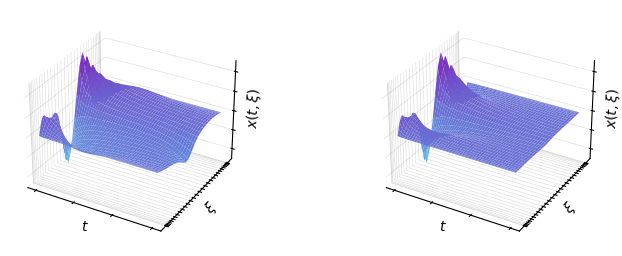

In [1]:
from experiments.__init__ import create_config, figures
from IPython.display import display
import matplotlib.pyplot as plt

config = create_config(system="burgers", seed=42)
cache_dir = f"./cache_seed{config.seed}"
figures.save_config_table(config)
figures.show_spec(config, keys=figures.DEFAULT_CONFIG_KEYS, title="Burgers configuration")
fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

### 4.1.2 Data Generation

In [2]:
from data import load_or_generate

n_trajectories = 200
n_candidates = 256
n_MC = 200

data_train, data_val, meta = load_or_generate(config, n_trajectories=n_trajectories, controller=config.ocp.LQR)
data = data_train  # Keep using 'data' for backward compatibility

summary_df = figures.save_data_summary_table(config, data)

display(summary_df.style.hide(axis="index"))

$N_{\mathrm{traj}}$,$|\mathcal{D}|$,t (max),|x| (mean),|x| (max),$\|x\|$ (mean),$\|x\|$ (max)
200,22656,5.513738,0.293815,2.189853,0.558423,1.324890


### 4.1.3 Training

Training 4 models on cpu...

--- Loading GradQRNet from cache ---

--- Loading GradQRNet (sup) from cache ---

--- Loading GradQRNet (pre) from cache ---

--- Loading GradQRNet (ad) from cache ---


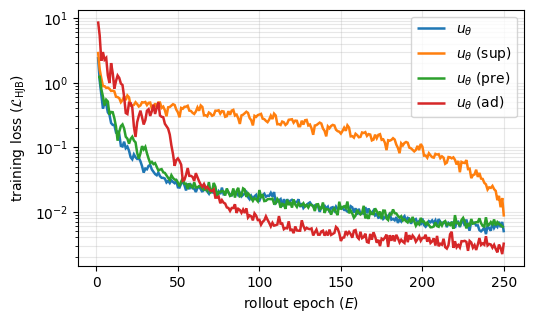

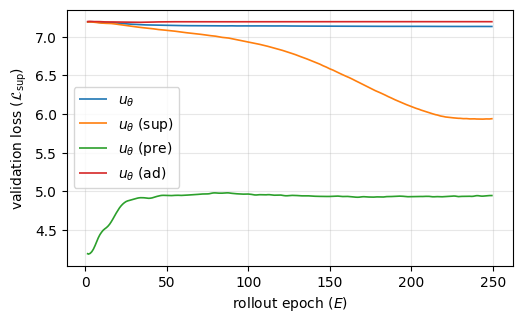

In [3]:
from controls.train import TrainConfig
from controls.model_factory import train_controllers

controller_configs = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (sup)": {"enabled": True},
    "GradQRNet (pre)": {"enabled": True},
    "GradQRNet (ad)": {"enabled": True},
}

cfg = TrainConfig(batch_size=16*int(config.n_states), n_candidates=n_candidates, horizon=1, rollouts=250, lambda_sup_base=2)

figures.save_params_table(cfg, "traincfg.tex", title="Training Configuration", config=config)

trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,  
    val_data=data_val,
    controller_configs=controller_configs,
)

figures.plot_training_losses(
    config=config,
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
)
plt.show()

figures.plot_training_val_mse(
    config=config,
    histories=histories,
    controller_configs=controller_configs,
)
plt.show()

### 4.1.4 Results

In [4]:
from simulation import monte_carlo

controllers = [("LQR (Baseline)", config.ocp.LQR),] + [(name, trained_controllers[name]) for name in trained_controllers.keys()]

results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo.tex")

100%|██████████| 200/200 [01:15<00:00,  2.66it/s]


,LQR (Baseline),GradQRNet,GradQRNet (sup),GradQRNet (pre),GradQRNet (ad)
Stability (S),75.0%,78.0%,78.5%,76.0%,81.5%
Cost J (mean),0.58,0.61,0.60,0.59,0.67


,Model,Stability $S$,Cost $J$ (mean)
0,LQR (Baseline),0.750,0.583605
1,GradQRNet,0.780,0.611176
2,GradQRNet (sup),0.785,0.600457
3,GradQRNet (pre),0.760,0.590321
4,GradQRNet (ad),0.815,0.670392


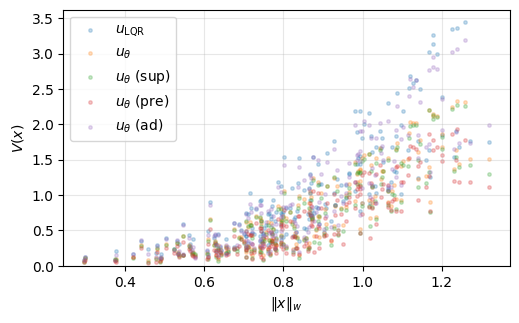

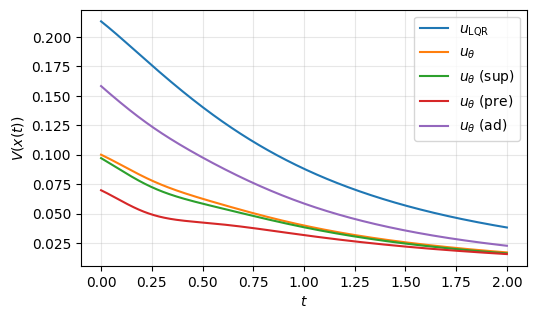

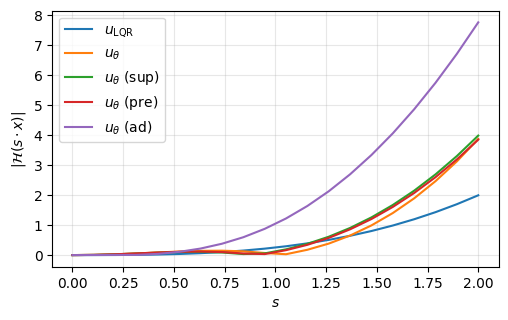

In [5]:
figures.plot_value_analysis_combined(
    config=config,
    controllers=controllers,
    n=200,
    tspan=(0.0, 2.0),
    Nt=400,
)
plt.show()

In [6]:
controller_configs = {
    "GradQRNet (sup/ad)": {"enabled": True}, # 512 candidates
    "GradQRNet (pre/sup)": {"enabled": True},
    "GradQRNet (pre/ad)": {"enabled": True},
    "GradQRNet (pre/sup/ad)": {"enabled": True},
}

In [7]:
trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,  
    val_data=data_val,
    controller_configs=controller_configs,  # Use the config defined above
)

Training 4 models on cpu...

--- Loading GradQRNet (pre/sup) from cache ---

--- Loading GradQRNet (sup/ad) from cache ---

--- Loading GradQRNet (pre/ad) from cache ---

--- Loading GradQRNet (pre/sup/ad) from cache ---


In [8]:
controllers = [(name, trained_controllers[name]) for name in trained_controllers.keys()]

results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo_combined.tex")

100%|██████████| 200/200 [02:01<00:00,  1.64it/s]


,GradQRNet (pre/sup),GradQRNet (sup/ad),GradQRNet (pre/ad),GradQRNet (pre/sup/ad)
Stability (S),73.0%,76.0%,72.0%,63.5%
Cost J (mean),0.68,0.69,0.64,0.64


,Model,Stability $S$,Cost $J$ (mean)
0,GradQRNet (pre/sup),0.730,0.675372
1,GradQRNet (sup/ad),0.760,0.686659
2,GradQRNet (pre/ad),0.720,0.640165
3,GradQRNet (pre/sup/ad),0.635,0.636038


## 4.2 Generalization and Robustness

### 4.2.1 Setup

**Allen-Cahn configuration**

system,seed,n_states,n_controls,t1_initial,nu,control_width,ic_modes,ic_scale,ic_basis
allen_cahn,42,32,1,10,0.100000,0.400000,9,1.000000,cosine


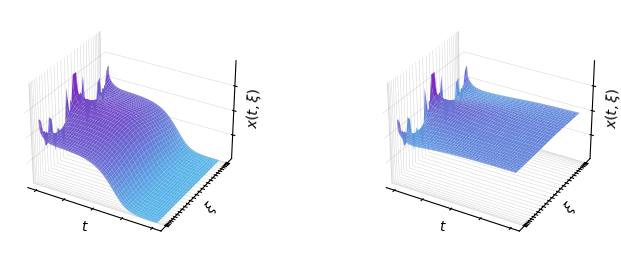

In [23]:
config = create_config(system="allen_cahn")
figures.save_config_table(config)
figures.show_spec(config, keys=figures.DEFAULT_CONFIG_KEYS, title="Allen-Cahn configuration")

fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

### 4.2.2 Data Generation

In [24]:
from data import load_or_generate

n_trajectories = 20
n_candidates = 512



data_ac_train, data_ac_val, meta_ac = load_or_generate(
    config, n_trajectories=n_trajectories, controller=config.ocp.LQR)

summary_ac = figures.save_data_summary_table(config, data_ac_train)
display(summary_ac.style.hide(axis="index"))

$N_{\mathrm{traj}}$,$|\mathcal{D}|$,t (max),|x| (mean),|x| (max),$\|x\|$ (mean),$\|x\|$ (max)
20,3134,7.989534,0.300905,1.496013,0.457117,1.094985


### 4.2.3 Training

In [25]:
controller_configs_ac = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (ad)": {"enabled": True},
    "GradQRNet (pre/sup)": {"enabled": True},
    "GradQRNet (sup/ad)": {"enabled": True},
}

cfg_ac = TrainConfig(batch_size=16*int(config.n_states), rollouts=25, horizon=20, n_candidates=n_candidates, dt_min=5e-4, lambda_sup_base=1e3, unsup_lr=2e-4) # r=20, h=25

figures.save_params_table(cfg_ac, "allen_cahn_traincfg.tex", title="Training configuration", config=config)

figures.show_spec(
    cfg_ac, 
    keys=["sup_epochs", "sup_lr", "rollouts", "unsup_lr", "horizon", "batch_size"], 
    title="Training Configuration"
)


trained_models_ac, trained_controllers_ac, histories_ac = train_controllers(
    config=config,
    train_cfg=cfg_ac,
    data=data_ac_train,
    val_data=data_ac_val,
    controller_configs=controller_configs_ac,
)


**Training Configuration**

sup_epochs,sup_lr,rollouts,unsup_lr,horizon,batch_size
1,0.001000,25,0.000200,20,512


Training 4 models on cpu...

--- Loading GradQRNet from cache ---

--- Loading GradQRNet (pre/sup) from cache ---

--- Loading GradQRNet (ad) from cache ---

--- Loading GradQRNet (sup/ad) from cache ---


### 4.2.4 Results

In [26]:
controllers = [(name, trained_controllers_ac[name]) for name in trained_controllers_ac.keys()]

results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo.tex")

  0%|          | 0/200 [00:00<?, ?it/s]

  1%|          | 2/200 [00:01<01:39,  1.99it/s]capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.



KeyboardInterrupt: 

In [13]:
results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC, dist=2.5, K=18)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo_far.tex")

100%|██████████| 200/200 [07:10<00:00,  2.15s/it]


,GradQRNet,GradQRNet (pre/sup),GradQRNet (ad),GradQRNet (sup/ad)
Stability (S),22.0%,21.0%,23.5%,21.0%
Cost J (mean),1.87,1.52,1.95,2.12


,Model,Stability $S$,Cost $J$ (mean)
0,GradQRNet,0.220,1.871536
1,GradQRNet (pre/sup),0.210,1.519105
2,GradQRNet (ad),0.235,1.945101
3,GradQRNet (sup/ad),0.210,2.121117


In [14]:
from simulation import monte_carlo_nu_mismatch

nu_baseline = config.ocp.nu
nu_eval = 0.09  # reduced diffusion
print(f"Model mismatch: train ν={nu_baseline}, eval ν={nu_eval}")
results = monte_carlo_nu_mismatch(
    config.ocp, config, controllers, nu_eval=nu_eval, n_MC=n_MC, verbose=0
)
figures.show_monte_carlo_results(results)
df = figures.save_monte_carlo_results(
    results, config=config, savepath="monte_carlo_nu_mismatch.tex"
)
display(df.style.hide(axis="index"))

Model mismatch: train ν=0.1, eval ν=0.09


100%|██████████| 200/200 [05:22<00:00,  1.61s/it]


,GradQRNet,GradQRNet (pre/sup),GradQRNet (ad),GradQRNet (sup/ad)
Stability (S),42.0%,41.0%,44.0%,35.5%
Cost J (mean),0.68,0.64,0.84,0.61


Model,Stability $S$,Cost $J$ (mean)
GradQRNet,0.420000,0.680691
GradQRNet (pre/sup),0.410000,0.642556
GradQRNet (ad),0.440000,0.835583
GradQRNet (sup/ad),0.355000,0.614023


In [ ]:
sigma_sde = 0.002  # noise strength
dt_sde = 0.5   # Euler-Maruyama step
n_MC = 100
print(f"SDE Monte Carlo: σ={sigma_sde}, dt={dt_sde}, n_MC={n_MC}")
results = monte_carlo(
    config.ocp, config, controllers,
    n_MC=n_MC,
    sigma=sigma_sde, dt_sde=dt_sde, random_seed=42, verbose=1
)
figures.show_monte_carlo_results(results)
df = figures.save_monte_carlo_results(
    results, config=config, savepath="monte_carlo_sde.tex"
)
display(df.style.hide(axis="index"))

SDE Monte Carlo: σ=0.002, dt=0.5, n_MC=100

Evaluating GradQRNet...


100%|██████████| 100/100 [03:48<00:00,  2.28s/it]



Evaluating GradQRNet (pre/sup)...


 24%|██▍       | 24/100 [00:37<02:06,  1.67s/it]

## 4.3 Scalability to Data-Scarse Regimes

### 4.3.1 Setup

KS only (top 5):  [-7.99999999e-02 -7.99999998e-02  9.12097717e-11  7.45000000e-01
  7.45000000e-01]
KS + alpha (top 5): [-7.99999999e-02 -7.99999998e-02  9.12097717e-11  7.45000000e-01
  7.45000000e-01]
Number unstable (KS only):  3
Number unstable (KS + alpha): 3
Closed-loop (top 5): [-0.82941214 -0.80329385 -0.43345682 -0.31797127 -0.0929559 ]
Closed-loop stable: True
Stabilizability matrix rank: 2 / 2


**Kuramoto-Sivashinsky configuration**

system,seed,n_states,n_controls,t1_initial,nu,control_width,ic_modes,ic_scale,ic_basis
kuramoto_sivashinsky,42,96,4,5,0.255000,0.200000,3,2,both


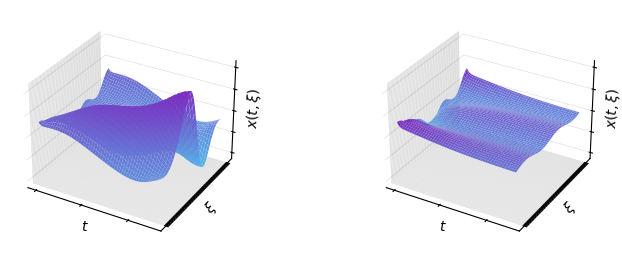

In [16]:
config = create_config(system="kuramoto_sivashinsky", nu=0.255, ic_scale=2, t1_initial=5, t1_max=20, ic_modes=3)

cache_dir = f"./cache_seed{config.seed}"
figures.save_config_table(config)
figures.show_spec(config, keys=figures.DEFAULT_CONFIG_KEYS, title="Kuramoto-Sivashinsky configuration")
fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

In [17]:
from simulation import monte_carlo
controllers = [("LQR (Baseline)", config.ocp.LQR)]# + [(name, trained_controllers[name]) for name in trained_controllers.keys()]
results = monte_carlo(config.ocp, config, controllers, n_MC=100)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo.tex")

100%|██████████| 100/100 [00:51<00:00,  1.93it/s]


,LQR (Baseline)
Stability (S),71.0%
Cost J (mean),31.32


,Model,Stability $S$,Cost $J$ (mean)
0,LQR (Baseline),0.71,31.315494


### 4.3.2 Data Generation

In [18]:
n_trajectories = 5
n_candidates = 384      # 50 worked, 724

#data_train, data_val, meta = load_or_generate(config, n_trajectories=n_trajectories, controller=config.ocp.LQR)
#data = data_train  # Keep using 'data' for backward compatibility

#summary_df = figures.save_data_summary_table(config, data)

#display(summary_df.style.hide(axis="index"))

### 4.3.3 Training

**Training configuration**

sup_epochs,sup_lr,unsup_lr,horizon,batch_size,n_candidates,dt_min,dt_max
1,0.001000,0.000200,20,1536,384,0.000000,1


Training 6 models on cpu...

--- Loading GradQRNet from cache ---

--- Loading GradQRNet (ad8) from cache ---

--- Loading GradQRNet (ad32) from cache ---

--- Loading GradQRNet (ad128) from cache ---

--- Loading GradQRNet (ad512) from cache ---

--- Loading GradQRNet (ad2048) from cache ---


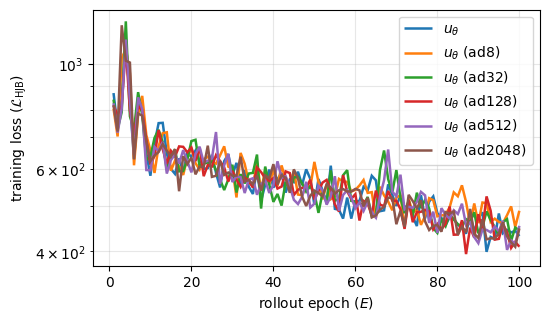

In [21]:


#ic scale = 0.25, dt_min=none worked, rollouts 50-100, unsup lr 1e-4
controller_configs = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (ad8)": {"enabled": True, "n_candidates": 8},
    "GradQRNet (ad32)": {"enabled": True, "n_candidates": 32},
    "GradQRNet (ad128)": {"enabled": True, "n_candidates": 128},
    "GradQRNet (ad512)": {"enabled": True, "n_candidates": 512},
    "GradQRNet (ad2048)": {"enabled": True, "n_candidates": 2048},


    #"GradQRNet (ad6144)": {"enabled": True, "n_candidates": 6144},

    #"GradQRNet (sup/ad384)": {"enabled": True},
}

cfg_ks = TrainConfig(batch_size=16*int(config.n_states), n_candidates=n_candidates, horizon=20, dt_min=1e-7, rollouts=100, unsup_lr=2e-4, lambda_sup_base=1e3) # 25 rollouts workd


figures.save_params_table(cfg_ks, "traincfg.tex", title="Training Configuration", config=config)

figures.show_spec(
    cfg_ks,
    keys=["sup_epochs", "sup_lr", "unsup_epochs", "unsup_n_steps", "unsup_lr", "horizon", "batch_size", "n_candidates", "dt_min", "dt_max"],
    title="Training configuration"
)

trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg_ks,
    controller_configs=controller_configs,
)

figures.plot_training_losses(
    config=config,
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
)
plt.show()



### 4.3.4 Results

In [20]:
controllers = [("LQR (Baseline)", config.ocp.LQR)] + [(name, trained_controllers[name]) for name in trained_controllers.keys()]
results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo.tex")

100%|██████████| 200/200 [05:14<00:00,  1.57s/it]


,LQR (Baseline),GradQRNet,GradQRNet (ad8),GradQRNet (ad32),GradQRNet (ad128),GradQRNet (ad512),GradQRNet (ad2048)
Stability (S),67.5%,73.0%,80.5%,72.5%,81.5%,70.0%,75.5%
Cost J (mean),35.07,34.21,34.76,34.00,35.44,34.14,34.56


,Model,Stability $S$,Cost $J$ (mean)
0,LQR (Baseline),0.675,35.067082
1,GradQRNet,0.730,34.209004
2,GradQRNet (ad8),0.805,34.756235
3,GradQRNet (ad32),0.725,34.000074
4,GradQRNet (ad128),0.815,35.442446
5,GradQRNet (ad512),0.700,34.144667
6,GradQRNet (ad2048),0.755,34.556271
